In [6]:
import argparse
import glob
import numpy as np
import pandas as pd
import tables as tb
from   typing      import Callable
from   typing      import Optional
from   typing      import List
from   pandas      import DataFrame
from   pandas      import Series

from sklearn.neighbors import NearestNeighbors

from scipy.interpolate import griddata

from invisible_cities.reco.corrections import read_maps, apply_all_correction
from invisible_cities.types.symbols import NormStrategy

def get_args():
    parser = argparse.ArgumentParser(
        description="Process a NEXT100 run and build summaries")
    parser.add_argument(
        "-r", "-run", "--run",
        dest="run_number",
        type=int,
        required=True,
        help="Run number to analyse, e.g. 15107")
    parser.add_argument(
        "-m", "--map",
        dest="map_name",
        type=str,
        default='map_MC_4bar_15063.h5',
        help="Name of the correction map")
    parser.add_argument(
        "-d", "--dim",
        dest="dimension",
        type=int,
        default=3,
        help="Number of dimensions for clustering algorithm")
    parser.add_argument(
        "-w", "--wf",
        dest="wf_selection",
        action='store_true',
        help="Pass if you want the script to perform cuts + select WF. If not passed, only saves summary")
    parser.add_argument(
        "-s", "--save",
        dest="save_name",
        type=str,
        default="run_summary.h5",
        help="Name of the file to save")
    parser.add_argument(
        "-l", "--ldc",
        dest="ldc_name",
        type=str,
        default="*",
        help="Name of the ldc to run over")
    parser.add_argument(
        "-n", "--nhit",
        dest="drop_nhits",
        type=int,
        default=3,
        help="Number of hits to drop a cluster")
    parser.add_argument(
        "-c", "--corr",
        dest="corr_type",
        type=str,
        default="2D",
        help="Type of map, 2D or 3D")
    return parser.parse_args()

# args        = get_args()
run_number  = 15589 #args.run_number 
map_name    = 'rough_geometry_map_v2.h5' #args.map_name
save_name   = '' #args.save_name
ldc_name    = 'ldc1' #args.ldc_name
drop_nhits  = 3 #args.drop_nhits
corr_type   = "2D" #args.corr_type

#just add ldc tag to saved file if ldc is not all
if ldc_name != '*':
    save_name = ldc_name + save_name

drop_cluster_dim = 3 #args.dimension
wf_selection = False #args.wf_selection

energy_windows = [(0.47, 0.67), (1.55, 1.8), (2.6, 9)]

source_path = '/mnt/netapp1/Store_next_data/NEXT100/data/{run_n}/hdf5/prod/*/*/sophronia/trigger2/'.format(run_n = run_number)
data_path = source_path + '{}/*'.format(ldc_name)

store_path  = '/mnt/lustre/scratch/nlsas/home/usc/ie/mpm/NEXT100/data/HE_runs/' 
save_path_summary = store_path + '/{run_n}/'.format(run_n = run_number) + save_name
map_path = store_path + map_name

def lineal(x, a, b):
    return a * x + b

def in_range(x, min_, max_):
    return (x > min_) & (x < max_)

def get_fname_info(path):
    file = path.split('/')[-1]
    split_name = file.split('_')
    run_n, file_n, ldc_n = split_name[1], split_name[2], split_name[3]
    return run_n, file_n, ldc_n

def drop_isolated_clusters(distance: List[float] = [16., 16., 4.], nhit: int = 3,
                           variables: List[str] = []) -> Callable:
    '''
    If len(distance) == 2, it will perform on X, Y
    If len(distance) == 3, it will perform on X, Y, Z
    '''
    ndim = len(distance)
    dist = np.sqrt(ndim)

    def drop(df: pd.DataFrame) -> pd.DataFrame:
        if len(df) == 0:
            return df
        coords = []

        coords.append(df.X.values / distance[0])
        coords.append(df.Y.values / distance[1])

        if ndim == 3:
            coords.append(df.Z.values / distance[2])

        coords = np.column_stack(coords)

        try:
            nbrs = NearestNeighbors(radius=dist, algorithm='ball_tree').fit(coords)
            neighbors = nbrs.radius_neighbors(coords, return_distance=False)
            mask = np.array([len(neigh) > nhit for neigh in neighbors])
        except Exception as e:
            print(f"Error in NearestNeighbors: {{e}}")
            return df.iloc[:0]  # fallback: return empty

        pass_df = df.loc[mask].copy()

        if not pass_df.empty and variables:
            with np.errstate(divide='ignore', invalid='ignore'):
                columns = pass_df.loc[:, variables]
                scale = df[variables].sum().values / columns.sum().values
                columns *= scale
                pass_df.loc[:, variables] = columns

        return pass_df

    return drop

def get_corr(filename, n_norm=1000):
    krmap = pd.read_hdf(filename, "/krmap")
    meta  = pd.read_hdf(filename, "/mapmeta")
    dtxy_map = krmap.loc[:, list("zxy")].values
    e0_map   = krmap.e0.values
    
    dt_norm   = np.random.rand(  n_norm)*1*meta.iloc[0].bin_size_z
    xy_norm   = np.random.rand(2,n_norm)*5*meta.iloc[0].bin_size_x
    dtxy_norm = np.stack([dt_norm, *xy_norm], axis=1)
    norm      = griddata(dtxy_map, e0_map, dtxy_norm, method="linear").mean()
    def corr(x, y, dt, t, method="nearest"): #t is not used but added just to be equal to the other corr function  
        dtxy_data = np.stack([dt, x, y], axis=1)
        e_data   = griddata(dtxy_map, e0_map, dtxy_data, method=method)
        return norm / e_data
    return corr

def hits_summary(group, fname, coords = ['X', 'Y', 'Z'], ener = 'Ec'):
    def dcoord(group, coords, i):
        c = coords[i]
        return group[c].max() - group[c].min()
    def barycenter(group, coords, i):
        return (group[coords[i]] * group['Q']).sum() / group['Q'].sum() #changed to Q because makes more sense
    
    run_n, file_n, ldc_n = get_fname_info(fname)
    
    return pd.Series({
        'run_n': str(run_n),
        'file_n': str(file_n),
        'ldc_n': str(ldc_n),
        'time': group['time'].unique()[0],
        'dX': dcoord(group, coords, 0),
        'dY': dcoord(group, coords, 1),
        'dZ': dcoord(group, coords, 2),
        'Xmin': group[coords[0]].min(),
        'Ymin': group[coords[1]].min(),
        'Zmin': group[coords[2]].min(), 
        'Rmax': np.sqrt(group['X']**2 + group['Y']**2).max(),
        'Xmax': group[coords[0]].max(),
        'Ymax': group[coords[1]].max(),
        'Zmax': group[coords[2]].max(),
        'X_bary': barycenter(group, coords, 0),
        'Y_bary': barycenter(group, coords, 1),
        'Z_bary': barycenter(group, coords, 2),
        'total_E': group['E'].sum(),
        'total_energy': group[ener].sum(),
        'num_hits': int(len(group)),
    })


def get_dropped_hits_info(df, df_drop):
    '''
    Takes the original df and the df with dropped hits to extract all this info
    '''
    # from the original DF, select the dropped and non dropped hits
    dropped_hits = df.reset_index(drop=True).merge(df_drop.drop(columns = 'Ec').reset_index(drop=True), how='outer', indicator=True).query('_merge == "left_only"').drop(columns='_merge')
    nondrop_hits = df.reset_index(drop=True).merge(df_drop.drop(columns = 'Ec').reset_index(drop=True), how='outer', indicator=True).query('_merge == "both"').drop(columns='_merge')
    assert len(dropped_hits) + len(nondrop_hits) == len(df)

    # pick per non dropped event the zrange to select the dropped hits, merge and create the mask 
    z_ranges = nondrop_hits.groupby(['event', 'npeak']).agg(Zmin = ('Z', 'min'), Zmax = ('Z', 'max'))
    dropped_hits = dropped_hits.merge(z_ranges, on=['event', 'npeak'], how='left')
    inZrange_mask = dropped_hits['Z'].between(dropped_hits['Zmin'], dropped_hits['Zmax'])

    # select both dropped hits (in and out of the event)
    reco_drop_in = dropped_hits[inZrange_mask]
    reco_drop_out = dropped_hits[~inZrange_mask]
    #summarize their info
    info_in = reco_drop_in.groupby(['event', 'npeak']).agg(Ec_drop_in = ('Ec', 'sum'), nhits_drop_in = ('Ec', 'count')).reset_index()
    info_out = reco_drop_out.groupby(['event', 'npeak']).agg(Ec_drop_out = ('Ec', 'sum'), nhits_drop_out = ('Ec', 'count')).reset_index()
    return info_in, info_out

def create_hits_summary(reco, corr_fun, dropper, fname):
    # Correct energy
    factor = corr_fun(reco.X, reco.Y, reco.Z, reco.time)
    #correct energy in the borders (for NaN hits)
    factor_border = corr_fun([479],[0],[0],[1])

    reco['Ec'] = reco.E * factor
    reco["Ec_border"] = reco.E * factor_border
    # add the latter energy
    reco["Ec"] = reco["Ec"].fillna(reco["Ec_border"])

    reco_full = reco.copy()
    
    # drop isolated clusters
    reco = reco.groupby(['event', 'npeak'], group_keys=False).apply(dropper)

    # get dropped clusters info
    info_in, info_out = get_dropped_hits_info(reco_full, reco)

    # do summary
    reco_summary = reco.groupby(['event', 'npeak']).apply(lambda group: hits_summary(group, fname)).reset_index()

    # add dropped clusters info to summary
    reco_summary = reco_summary.merge(info_in, on = ['event', 'npeak'], how = 'outer').fillna({'nhits_drop_in': 0})
    reco_summary = reco_summary.merge(info_out, on = ['event', 'npeak'], how = 'outer').fillna({'nhits_drop_out': 0})
    reco_summary = reco_summary.dropna(thresh=5).astype({'num_hits':'int', 'nhits_drop_out': 'int', 'nhits_drop_in': 'int'}) #clean just in case there is some peak with all dropped hits
    #this was a quick fix, maybe not the best because I have to return int again
    # I would need some kind of check that just dont merges events that have all dropped
    return reco_summary

def apply_dst_cuts(dst, s1_DT_cut = [0.32, 500]):
    # Had to decouple cuts 
    #1S1
    dst_S1 = dst[dst.nS1 == 1]
    nev_S1 = len(dst_S1.event.unique())
    #1S2
    dst_S2 = dst_S1[dst_S1.nS2 == 1]
    nev_S2 = len(dst_S2.event.unique())
    #DT > 0
    dst_DT = dst_S2[dst_S2.DT > 0].copy()
    nev_DT = len(dst_DT.event.unique())
    #alphas
    dst_DT['limS1e'] = lineal(dst_DT.DT, s1_DT_cut[0], s1_DT_cut[1])
    dst_al = dst_DT[dst_DT.S1e < dst_DT.limS1e]
    nev_al = len(dst_al.event.unique())
    return dst_DT, [nev_S1, nev_S2, nev_DT, nev_al]

def apply_fid_cuts(reco):
    # R
    reco_r = reco[in_range(reco.Rmax , 0, 450)]
    nev_r = len(reco_r.event.unique())
    # Z
    reco_fid = reco_r[in_range(reco_r.Zmin , 20, 1369*0.865) & in_range(reco_r.Zmax , 20, 1369*0.865)]
    nev_f = len(reco_fid.event.unique())
    return reco_fid, [nev_r, nev_f]

def apply_window_cuts(reco, windows = [(0.45, 0.65), (1.4, 1.8), (2.2, 3)]):
    combined_mask = np.zeros_like(reco.total_energy, dtype=bool)
    nev_win = []
    for wd in windows:
        mask = in_range(reco.total_energy, wd[0], wd[1])
        nev_win.append(len(reco[mask].event.unique()))
        combined_mask |= mask
    return reco[combined_mask], nev_win



files = sorted(glob.glob(data_path + '*'), key=lambda x: (x.split('/')[-2], int(x.split('/')[-1].split('_')[2])))

# Energy correction
if corr_type == "2D":
    maps = read_maps(map_path)

    get_coef  = apply_all_correction(maps
                                    , apply_temp = False
                                    , norm_strat = NormStrategy.kr)
if corr_type == "3D":
    get_coef = get_corr(map_path)

# Cluster dropping
if drop_cluster_dim == 2:
    dist = [16., 16.]
if drop_cluster_dim == 3:
    dist = [16., 16., 4.]

dropper = drop_isolated_clusters(distance = dist, nhit = drop_nhits, variables = ['Ec'])

# time_to_Z = get_df_to_z_converter(maps) if maps.t_evol is not None else identity

eff = np.array([0] * 10) # to compute efficiencies

# for i, f in enumerate(files):
#     nev = []
#     try:
#         dst = pd.read_hdf(f, 'DST/Events')
#         reco = pd.read_hdf(f, 'RECO/Events')
#     except Exception as e:
#         print(f"Skipping corrupted/invalid file: {f}")
#         print(f"Error: {e}")
#         continue

#     if reco.empty:
#         print(f"Skipping empty file: {f}")
#         continue

#     if wf_selection:
#         # For wf selection, we apply first some cuts in the DST so we do drop_clusters over less events
#         nev_initial = len(dst.event.unique())
#         nev.extend([nev_initial])
#         # apply dst cuts
#         dst, nev_dst = apply_dst_cuts(dst)
#         nev.extend(nev_dst)
#         reco = reco[np.isin(reco.event, dst.event.unique())]

#         # check no dst is empty after cuts
#         if dst.empty:
#             print(f"DST empty after initial cuts: {f}")
#             continue

#     # create summary
#     reco_summary = create_hits_summary(reco, get_coef, dropper, f)

#     if wf_selection:
#         # and also we directly deliver everything with cuts
#         #apply fid cuts
#         reco_summary, nev_reco = apply_fid_cuts(reco_summary)
#         nev.extend(nev_reco)

#         # apply energy window cuts
#         reco_summary, nev_win = apply_window_cuts(reco_summary, windows=energy_windows)
#         nev.extend(nev_win)
#         dst = dst[np.isin(dst.event, reco_summary.event.unique())] # not saved but no problem

#         #create df for wf selection (creo que me vale directamente el reco, porque ya tiene toda la info)
#         selected_events = reco_summary.drop(columns = ['time', 'npeak',
#                                                     'dX', 'dY', 'dZ', 
#                                                     'Xmin', 'Ymin', 'Zmin', 
#                                                     'Rmax', 'Xmax','Ymax','Zmax',
#                                                     'X_bary','Y_bary','Z_bary',
#                                                     'total_E', 'num_hits'])
#         selected_events.to_hdf(save_path_summary, key = 'RUN/Selected_events', mode = 'a', append = True, complib="zlib", complevel=4)
#         eff += np.array(nev)
        
#     else: #decided not to save this for the WF selector
#         dst.to_hdf (save_path_summary, key = 'DST/Events', mode = 'a', append= True, complib="zlib", complevel=4)
#         reco_summary.to_hdf(save_path_summary, key = 'RECO/Events_summary', mode = 'a', append= True, complib="zlib", complevel=4)

#     print(i)

# if wf_selection:
#     eff_df = pd.DataFrame([eff],columns = ['total', '1S1', '1S2', 'DT', 'alphas', 'rad', 'z', 'SP', 'DEP', 'PP'])
#     eff_df.to_hdf(save_path_summary, 'RUN/eff', complib="zlib", complevel=4)

In [53]:
for i, f in enumerate(files):
    dst = pd.read_hdf(f, 'DST/Events')
    reco = pd.read_hdf(f, 'RECO/Events')

    factor = get_coef(reco.X, reco.Y, reco.Z, reco.time)
    reco['Ec'] = reco.E * factor
    #correct energy in the borders (for NaN hits)
    factor_border = get_coef([479],[0],[0],[1])
    reco["Ec_border"] = reco.E * factor_border
    # add the latter energy
    reco["Ec"] = reco["Ec"].fillna(reco["Ec_border"])

    reco_full = reco.copy()
    
    # drop isolated clusters
    reco = reco.groupby(['event', 'npeak'], group_keys=False).apply(dropper)

    dropped_hits = reco_full.reset_index(drop=True).merge(reco.drop(columns = 'Ec').reset_index(drop=True), how='outer', indicator=True).query('_merge == "left_only"').drop(columns='_merge')
    nondrop_hits = reco_full.reset_index(drop=True).merge(reco.drop(columns = 'Ec').reset_index(drop=True), how='outer', indicator=True).query('_merge == "both"').drop(columns='_merge')
    assert len(dropped_hits) + len(nondrop_hits) == len(reco_full)

    # pick per non dropped event the zrange to select the dropped hits, merge and create the mask 
    z_ranges = nondrop_hits.groupby(['event', 'npeak']).agg(Zmin = ('Z', 'min'), Zmax = ('Z', 'max'))
    dropped_hits = dropped_hits.merge(z_ranges, on=['event', 'npeak'], how='left')
    inZrange_mask = dropped_hits['Z'].between(dropped_hits['Zmin'], dropped_hits['Zmax'])

    # select both dropped hits (in and out of the event)
    reco_drop_in = dropped_hits[inZrange_mask]
    reco_drop_out = dropped_hits[~inZrange_mask]

    # reco_summary = create_hits_summary(reco, get_coef, dropper, f)
    # dst.to_hdf (save_path_summary, key = 'DST/Events', mode = 'a', append= True, complib="zlib", complevel=4)
    # reco_summary.to_hdf(save_path_summary, key = 'RECO/Events_summary', mode = 'a', append= True, complib="zlib", complevel=4)
    # print(i)
    break

In [54]:
reco_full

,event,time,npeak,Xpeak,Ypeak,nsipm,X,Y,Xrms,Yrms,Z,Q,E,Qc,Ec,track_id,Ep,Ec_border
0,8,1.751990e+09,37,58.275919,83.240983,1,-220.275,353.775,0.0,0.0,611.867625,7.227603,-4.504640,-1.0,-0.000026,-1,-1.0,-0.000033
1,8,1.751990e+09,37,58.275919,83.240983,1,212.125,-124.275,0.0,0.0,623.841500,7.801650,1.669304,-1.0,0.000009,-1,-1.0,0.000012
2,8,1.751990e+09,37,58.275919,83.240983,1,351.075,260.975,0.0,0.0,632.354000,9.426950,307.351731,-1.0,0.001966,-1,-1.0,0.002232
3,8,1.751990e+09,37,58.275919,83.240983,1,366.625,245.425,0.0,0.0,632.354000,9.170438,298.988517,-1.0,0.001894,-1,-1.0,0.002171
4,8,1.751990e+09,37,58.275919,83.240983,1,273.325,-279.275,0.0,0.0,636.194875,7.454491,85.769688,-1.0,0.000474,-1,-1.0,0.000623
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44002,722,1.751990e+09,30,53.253355,66.157571,1,273.325,-32.475,0.0,0.0,1331.746625,9.069082,223.165173,-1.0,0.001203,-1,-1.0,0.001621
44003,722,1.751990e+09,30,53.253355,66.157571,1,-173.625,-386.625,0.0,0.0,1355.756250,7.769871,86.307866,-1.0,0.000540,-1,-1.0,0.000627
44004,722,1.751990e+09,30,53.253355,66.157571,1,-34.675,245.925,0.0,0.0,1359.627500,7.197902,35.669951,-1.0,0.000190,-1,-1.0,0.000259
44005,722,1.751990e+09,30,53.253355,66.157571,1,335.525,-62.575,0.0,0.0,1371.805500,7.862590,23.820605,-1.0,0.000131,-1,-1.0,0.000173


In [55]:
reco['label'] = 0
reco_drop_in['label'] = 1
reco_drop_out['label'] = 2

/scratch/15277765/ipykernel_2779793/750529268.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  reco_drop_in['label'] = 1
/scratch/15277765/ipykernel_2779793/750529268.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  reco_drop_out['label'] = 2


In [56]:
reco_drop_in

,event,time,npeak,Xpeak,Ypeak,nsipm,X,Y,Xrms,Yrms,...,Q,E,Qc,Ec,track_id,Ep,Ec_border,Zmin,Zmax,label
2,8,1.751990e+09,37,58.275919,83.240983,1,273.325,-279.275,0.0,0.0,...,7.454491,85.769688,-1.0,0.000474,-1,-1.0,0.000623,632.35400,891.460125,1
3,8,1.751990e+09,37,58.275919,83.240983,1,88.725,230.375,0.0,0.0,...,7.679268,62.337941,-1.0,0.000329,-1,-1.0,0.000453,632.35400,891.460125,1
4,8,1.751990e+09,37,58.275919,83.240983,1,-220.275,-78.625,0.0,0.0,...,8.141265,57.343889,-1.0,0.000297,-1,-1.0,0.000416,632.35400,891.460125,1
5,8,1.751990e+09,37,58.275919,83.240983,1,288.875,292.075,0.0,0.0,...,7.117351,50.131840,-1.0,0.000294,-1,-1.0,0.000364,632.35400,891.460125,1
6,8,1.751990e+09,37,58.275919,83.240983,1,10.975,122.525,0.0,0.0,...,7.633321,61.113613,-1.0,0.000318,-1,-1.0,0.000444,632.35400,891.460125,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3274,722,1.751990e+09,30,53.253355,66.157571,1,243.225,322.675,0.0,0.0,...,7.763975,60.655844,-1.0,0.000363,-1,-1.0,0.000441,1248.65525,1267.331375,1
3275,722,1.751990e+09,30,53.253355,66.157571,1,273.325,198.775,0.0,0.0,...,8.129886,63.514510,-1.0,0.000354,-1,-1.0,0.000461,1248.65525,1267.331375,1
3276,722,1.751990e+09,30,53.253355,66.157571,1,351.075,307.625,0.0,0.0,...,7.372534,57.597720,-1.0,0.000492,-1,-1.0,0.000418,1248.65525,1267.331375,1
3277,722,1.751990e+09,30,53.253355,66.157571,1,319.975,337.725,0.0,0.0,...,7.760461,60.628389,-1.0,0.000554,-1,-1.0,0.000440,1248.65525,1267.331375,1


In [60]:
reco_label = reco[['event', 'npeak', 'X', 'Y', 'Z', 'label']].append(reco_drop_in[['event', 'npeak', 'X', 'Y', 'Z', 'label']]).append(reco_drop_out[['event', 'npeak', 'X', 'Y', 'Z', 'label']])

In [81]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from scipy.stats import binned_statistic_2d


def plot_realdata_2d_bins(df,
                          distance,
                          coords = ['X', 'Y', 'Z'],
                          value_col='energy',
                          statistic='sum',
                          colorbar_label='Energy (MeV)'):
    """
    Plot XY, XZ & YZ 2D maps for real data, using precomputed voxel coordinates
    and a specified aggregation (sum, max, mean, etc.).

    Parameters
    ----------
    df         : pd.DataFrame
        DataFrame with at least one column: value_col.
    coords     : np.ndarray of shape (N, 3)
        Array of voxel coordinates in (X, Y, Z) after binning or normalization.
    bin_edges  : tuple of 3 arrays
        (x_edges, y_edges, z_edges) for binning along each axis.
    value_col  : str, default 'energy'
        Column to aggregate and display.
    statistic  : str or callable, default 'sum'
        Aggregation per bin. Can be 'sum', 'mean', 'count', 'max', etc.
    colorbar_label : str or None
        Label for color bar. If None, auto-generated from value_col and statistic.
    """
    if value_col not in df.columns:
        raise KeyError(f"Column '{value_col}' not found in DataFrame.")

    if value_col == 'label':
        eps = 1e-10
    else:
        eps = 0

    x = df[coords[0]].values / distance[0]
    y = df[coords[1]].values / distance[1]
    z = df[coords[2]].values / distance[2]

    # Define your bin edges (must match voxelisation scheme)
    x_bins = np.arange(x.min(), x.max() + 1)
    y_bins = np.arange(y.min(), y.max() + 1)
    z_bins = np.arange(z.min(), z.max() + 1)

    val = df[value_col].values + eps

    # Define projections: (x_data, y_data, xedges, yedges, title, labels)
    projections = [
        (x, y, x_bins, y_bins, 'XY', ('X (mm)', 'Y (mm)')),
        (x, z, x_bins, z_bins, 'XZ', ('X (mm)', 'Z (mm)')),
        (y, z, y_bins, z_bins, 'YZ', ('Y (mm)', 'Z (mm)')),
    ]

    Hs = []
    for xdata, ydata, xedges, yedges, *_ in projections:
        H, *_ = binned_statistic_2d(
            xdata, ydata, val,
            statistic=statistic, bins=[xedges, yedges])
        Hs.append(np.nan_to_num(H, nan=0.0))

    vmin = 1e-10
    vmax = max(H.max() for H in Hs)

    cmap = plt.cm.viridis.copy()
    cmap.set_under('white')

    fig = plt.figure(figsize=(15, 5))
    gs = GridSpec(1, 4, width_ratios=[1, 1, 1, 0.05], wspace=0.3, figure=fig)

    axes = [fig.add_subplot(gs[i]) for i in range(3)]
    cax = fig.add_subplot(gs[3])

    for ax in axes:
        try:
            ax.set_box_aspect(1)
        except AttributeError:
            ax.set_aspect('equal', adjustable='box')

    im_for_cbar = None
    for ax, H, (xdata, ydata, xedges, yedges, title, (xlbl, ylbl)) in zip(
            axes, Hs, projections):

        im = ax.imshow(H.T, origin='lower',
                       extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
                       cmap=cmap, vmin=vmin, vmax=vmax,
                       aspect='auto')
        im_for_cbar = im

        for xedge in xedges:
            ax.axvline(xedge, color='white', linewidth=0)
        for yedge in yedges:
            ax.axhline(yedge, color='white', linewidth=0)

        ax.set_xlim(xedges[0], xedges[-1])
        ax.set_ylim(yedges[0], yedges[-1])
        ax.set_xlabel(xlbl)
        ax.set_ylabel(ylbl)
        # ax.set_title(title)

    if colorbar_label is None:
        colorbar_label = f"{value_col.capitalize()} ({statistic})"
    cbar = fig.colorbar(im_for_cbar, cax=cax)
    cbar.set_label(colorbar_label, size=15)

    plt.show()


import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from scipy.stats import binned_statistic_2d
import matplotlib.colors as mcolors


def plot_label_voxels(df,
                      distance,
                      value_col='label',
                      statistic='max',
                      colorbar_label=None):
    """
    Plot XY, XZ & YZ 2D projections of integer-valued voxel labels,
    using real data (no MC), with internal voxelisation based on distance.

    Parameters
    ----------
    df         : pd.DataFrame
        Must contain columns 'X', 'Y', 'Z' and a label column.
    distance   : tuple of 3 floats
        Voxel sizes along X, Y, Z axes (e.g., (1.0, 1.0, 1.0)).
    value_col  : str, default 'label'
        The name of the integer-valued label column.
    statistic  : str or callable, default 'max'
        Aggregation function per bin.
    colorbar_label : str or None
        Label for color bar. If None, generated from value_col and statistic.
    """
    if value_col not in df.columns:
        raise KeyError(f"Column '{value_col}' not found in DataFrame.")
    for dim in ['X', 'Y', 'Z']:
        if dim not in df.columns:
            raise KeyError(f"Column '{dim}' required in DataFrame.")

    # Compute voxel coordinates
    coords = np.column_stack([
        df.X.values / distance[0],
        df.Y.values / distance[1],
        df.Z.values / distance[2],
    ])

    # Compute bin edges
    x_bins = np.arange(np.floor(coords[:, 0].min()),
                       np.ceil(coords[:, 0].max()) + 1)
    y_bins = np.arange(np.floor(coords[:, 1].min()),
                       np.ceil(coords[:, 1].max()) + 1)
    z_bins = np.arange(np.floor(coords[:, 2].min()),
                       np.ceil(coords[:, 2].max()) + 1)

    x, y, z = coords[:, 0], coords[:, 1], coords[:, 2]
    val = df[value_col].values.astype(float)

    projections = [
        (x, y, x_bins, y_bins, 'XY', ('X (mm)', 'Y (mm)')),
        (x, z, x_bins, z_bins, 'XZ', ('X (mm)', 'Z (mm)')),
        (y, z, y_bins, z_bins, 'YZ', ('Y (mm)', 'Z (mm)')),
    ]

    Hs = []
    for xdata, ydata, xedges, yedges, *_ in projections:
        H, *_ = binned_statistic_2d(
            xdata, ydata, val,
            statistic=statistic, bins=[xedges, yedges])
        H = np.nan_to_num(H, nan=0.0).astype(int)
        Hs.append(H)

    # Auto-determine label count and colormap
    n_labels = int(df[value_col].max()) + 1
    cmap = plt.cm.get_cmap('tab20', n_labels)
    cmap = mcolors.ListedColormap([cmap(i) for i in range(n_labels)])
    norm = mcolors.BoundaryNorm(np.arange(-0.5, n_labels + 0.5), ncolors=n_labels)

    fig = plt.figure(figsize=(15, 5))
    gs = GridSpec(1, 4, width_ratios=[1, 1, 1, 0.05], wspace=0.3, figure=fig)

    axes = [fig.add_subplot(gs[i]) for i in range(3)]
    cax = fig.add_subplot(gs[3])

    for ax in axes:
        try:
            ax.set_box_aspect(1)
        except AttributeError:
            ax.set_aspect('equal', adjustable='box')

    im_for_cbar = None
    for ax, H, (xdata, ydata, xedges, yedges, title, (xlbl, ylbl)) in zip(
            axes, Hs, projections):

        im = ax.imshow(H.T, origin='lower',
                       extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
                       cmap=cmap, norm=norm, aspect='auto')
        im_for_cbar = im

        for xedge in xedges:
            ax.axvline(xedge, color='white', linewidth=0.3)
        for yedge in yedges:
            ax.axhline(yedge, color='white', linewidth=0.3)

        ax.set_xlim(xedges[0], xedges[-1])
        ax.set_ylim(yedges[0], yedges[-1])
        ax.set_xlabel(xlbl)
        ax.set_ylabel(ylbl)
        ax.set_title(title)

    if colorbar_label is None:
        colorbar_label = f"{value_col.capitalize()} ({statistic})"

    cbar = fig.colorbar(im_for_cbar, cax=cax, ticks=np.arange(n_labels))
    cbar.set_label(colorbar_label, size=15)

    plt.show()


In [70]:
ev = reco_full.event.unique()[1]

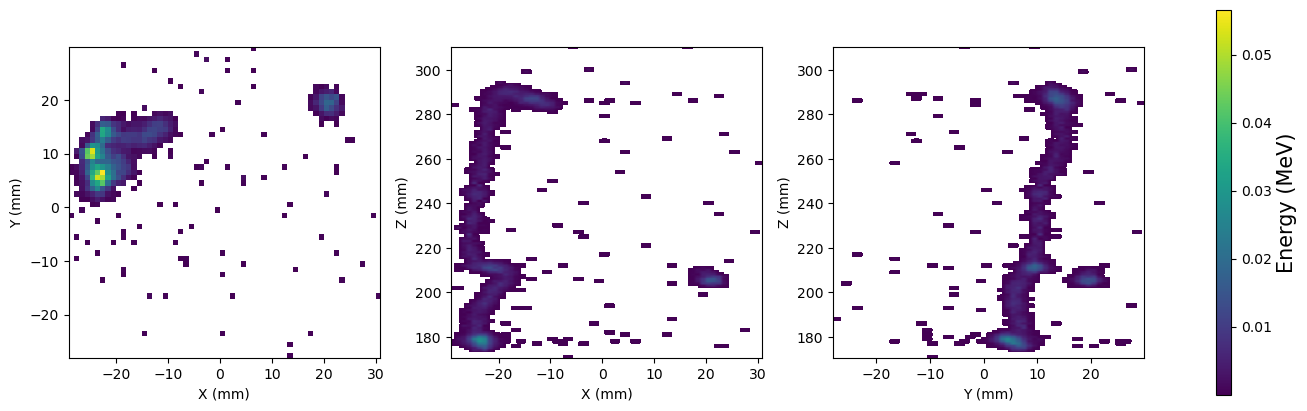

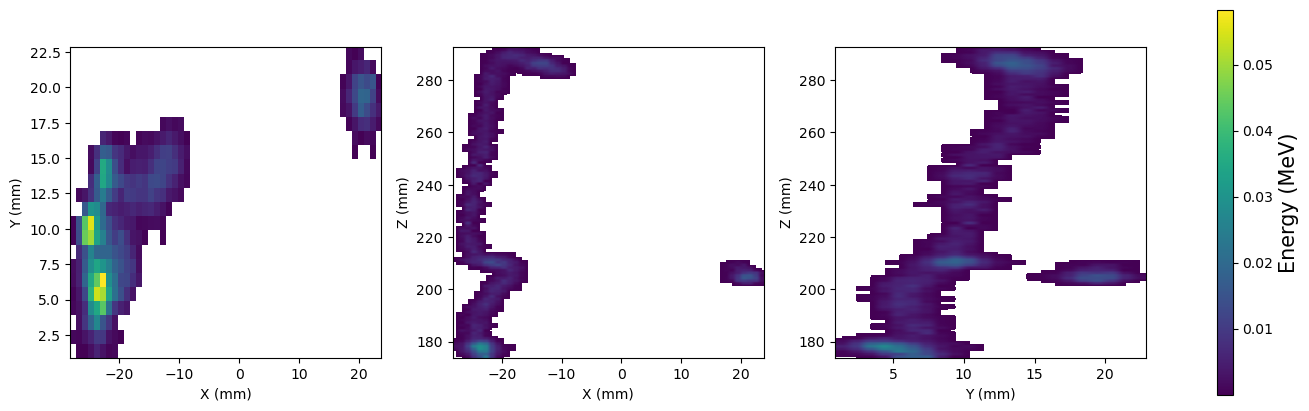

In [71]:
ev = 309 #393
plot_realdata_2d_bins(reco_full[reco_full.event == ev],
                [16, 16, 4],
                value_col = 'Ec',
                statistic = 'sum',
                colorbar_label = 'Energy (MeV)')
plot_realdata_2d_bins(reco[reco.event == ev],
                [16, 16, 4],
                value_col = 'Ec',
                statistic = 'sum',
                colorbar_label = 'Energy (MeV)')

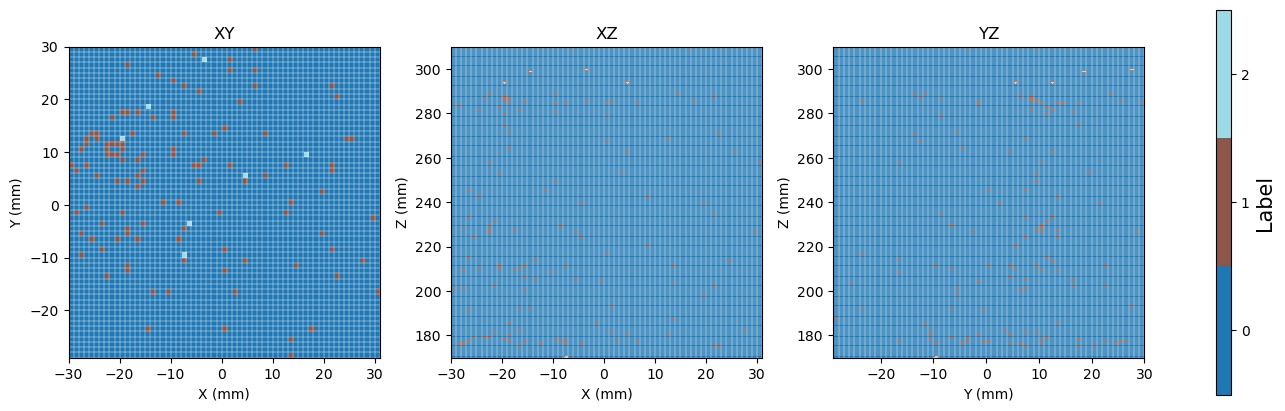

In [82]:
ev = 309 #393
plot_label_voxels(reco_label[reco_label.event == ev],
                [16, 16, 4],
                value_col = 'label',
                statistic = 'max',
                colorbar_label = 'Label')

In [78]:
# for ev in reco_full.event.unique():
#     print('EVENT {}'.format(ev))
#     plot_realdata_2d_bins(reco_full[reco_full.event == ev],
#                     [16, 16, 4],
#                     value_col = 'Ec',
#                     statistic = 'sum',
#                     colorbar_label = 'Energy (MeV)')
#     plot_realdata_2d_bins(reco[reco.event == ev],
#                     [16, 16, 4],
#                     value_col = 'Ec',
#                     statistic = 'sum',
#                     colorbar_label = 'Energy (MeV)')
    